<a href="https://colab.research.google.com/github/lisbethmesa-droid/proyecto-marsh-Gestion-proyectos/blob/main/PROYECTO_MARSH_gestion_estrategica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Especialización en Analítica Estratégica de Datos
### **Gestión Estratégica de Proyectos de Analítica**
### **Proyecto Integrador**

---
**Profesor: Camilo Bohorquez**

**Estudiantes:**
- Barrera Gabriela
- Herrera Ivanna
- Mesa Lisbeth

**Institución:** Universidad Pedagógica y Tecnológica de Colombia - UPTC  
**Programa:** Especialización en Analítica Estratégica de Datos  
**Año:** 2026 | Sogamoso, Boyacá

---

**Empresa caso de estudio:** Marsh Colombia  
**Modelos a Implementar:** Regresión Lineal · Regresión Logística  
**Dataset:** Pólizas de seguros - predicción de primas y renovación

---

#**Librerias**

In [1]:
from google.colab import drive
import pandas as pd
from pathlib import Path
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística (sesgo/skewness)
from scipy.stats import skew

# División de datos
from sklearn.model_selection import train_test_split

# Preprocesamiento: imputación, escalado, codificación
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

# Imputación avanzada (MICE)
from sklearn.experimental import enable_iterative_imputer  # necesario para habilitar IterativeImputer
from sklearn.impute import IterativeImputer

# Pipelines
from sklearn.pipeline import Pipeline

# Selección de variables
from sklearn.feature_selection import SelectKBest, f_regression

# Modelos de regresión (los 2 que se comparan)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Modelo base de referencia (para comparar contra algo ingenuo)
from sklearn.dummy import DummyRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#**Carga de Datos**

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
  print("No estás en Google Colab. Se omite el montaje de Google Drive.")


Mounted at /content/drive


In [3]:

rutas_posibles = [
    Path("dataset_polizas_sucio.xlsx"),
    Path("./data/dataset_polizas_sucio.xlsx"),
    Path("/content/dataset_polizas_sucio.xlsx"),
    Path("/content/drive/MyDrive/GESTION_ ESTRATEGICA _PROYECTO_ MARSH_/DATA ORIGINAL/dataset_polizas_sucio.xlsx"),
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró el archivo dataset_polizas_sucio.xlsx. "
        "Verifica la ruta exacta en tu Google Drive."
    )

df = pd.read_excel(ruta_dataset)

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado desde: /content/drive/MyDrive/GESTION_ ESTRATEGICA _PROYECTO_ MARSH_/DATA ORIGINAL/dataset_polizas_sucio.xlsx
Filas: 1284
Columnas: 53


In [6]:
df.head()

,id_venta,id_poliza,monto_prima,porcentaje_comision,valor_impuesto,monto_total_venta,fecha_venta,tipo_ramo,fecha_inicio_poliza,fecha_fin_poliza,...,indice_riesgo_combinado,num_tipos_sinistro,es_renovacion,es_cancelada,suma_asegurada_estimada,ramo_alto_riesgo,zona_costera,canal_distribucion,codigo_agente,observaciones
0,VTA0000001,POL000387,1.977802e+08,0.1995,37578244.77,2.353585e+08,2023-12-21,Multirriesgo,NaT,2024-10-11,...,226.525,3,0,0,1977802356,1,1,NaN,NaN,NaN
1,VTA0000002,POL000092,1.717520e+07,0.1629,3263287.33,2.043848e+07,2024-07-01,Manejo,2024-01-14,2025-01-14,...,44.876,2,1,0,171751965,0,0,NaN,NaN,NaN
2,VTA0000005,POL000505,4.917586e+05,0.1793,93434.14,5.851928e+05,2023-04-12,Fianza,2022-12-12,2023-12-12,...,0.715,1,0,0,4917586,0,1,NaN,NaN,NaN
3,VTA0000006,POL000252,1.250678e+06,0.1789,237628.73,1.488306e+06,2024-09-21,Todo Riesgo,2024-04-23,2025-04-23,...,7.890,2,0,0,12506775,1,0,NaN,NaN,NaN
4,VTA0000007,POL000217,3.755291e+06,0.0804,NaN,4.468796e+06,2025-01-27,Automóviles,NaT,2025-01-29,...,11.664,3,0,0,37552910,0,0,NaN,NaN,NaN


# **Clasificacion de Variables**

In [7]:
#Crear diccionario de variables con clasificación
clasificacion = {
    "id_venta": "Identificador",
    "id_poliza": "Identificador",
    "monto_prima": "Cuantitativa continua (Objetivo regresión)",
    "porcentaje_comision": "Cuantitativa continua",
    "valor_impuesto": "Cuantitativa continua",
    "monto_total_venta": "Cuantitativa continua",
    "fecha_venta": "Fecha",
    "tipo_ramo": "Cualitativa nominal",
    "fecha_inicio_poliza": "Fecha",
    "fecha_fin_poliza": "Fecha",
    "codigo_zona_sismica": "Identificador",
    "nivel_riesgo": "Cuantitativa continua",
    "estado_poliza": "Cualitativa nominal",
    "tipo_sector": "Cualitativa nominal",
    "ciudad": "Cualitativa nominal",
    "departamento": "Cualitativa nominal",
    "tamaño_empresa": "Cualitativa ordinal",
    "codigo_divipola": "Identificador",
    "nivel_riesgo_sismico": "Cuantitativa discreta",
    "latitud": "Cuantitativa continua",
    "longitud": "Cuantitativa continua",
    "sector_economico": "Cualitativa nominal",
    "riesgo_sector": "Cuantitativa continua",
    "aseguradora": "Cualitativa nominal",
    "num_sinistros": "Cuantitativa discreta",
    "monto_total_siniestros": "Cuantitativa continua",
    "monto_total_pagado": "Cuantitativa continua",
    "tipos_sinistro": "Cualitativa nominal",
    "sinistros_aprobados": "Cuantitativa discreta",
    "sinistros_rechazados": "Cuantitativa discreta",
    "duracion_poliza_dias": "Cuantitativa discreta",
    "ratio_siniestralidad": "Cuantitativa continua",
    "anio_venta": "Cuantitativa discreta",
    "mes_venta": "Cuantitativa discreta",
    "tiene_sinistro": "Cualitativa binaria (0/1)",
    "log_monto_prima": "Cuantitativa continua",
    "tamaño_empresa_num": "Cualitativa ordinal",
    "antiguedad_meses": "Cuantitativa continua",
    "trimestre_venta": "Cuantitativa discreta",
    "es_temporada_alta": "Cualitativa binaria (0/1)",
    "prima_diaria": "Cuantitativa continua",
    "ratio_aprobacion_sinistros": "Cuantitativa continua",
    "monto_promedio_sinistro": "Cuantitativa continua",
    "indice_riesgo_combinado": "Cuantitativa continua",
    "num_tipos_sinistro": "Cuantitativa discreta",
    "es_renovacion": "Cualitativa binaria (0/1)",
    "es_cancelada": "Cualitativa binaria (0/1) (Objetivo clasificación)",
    "suma_asegurada_estimada": "Cuantitativa continua",
    "ramo_alto_riesgo": "Cualitativa binaria (0/1)",
    "zona_costera": "Cualitativa binaria (0/1)",
    "canal_distribucion": "Cualitativa nominal",
    "codigo_agente": "Identificador",
    "observaciones": "Cualitativa texto libre"
}

# Crear dataframe con clasificación y tipo detectado
diccionario = pd.DataFrame({
    "Clasificación": [clasificacion.get(col, "Por definir") for col in df.columns],
    "Tipo_detectado": df.dtypes.astype(str)
})

# Mostrar tabla completa
pd.set_option('display.max_rows', None)
display(diccionario)

,Clasificación,Tipo_detectado
id_venta,Identificador,object
id_poliza,Identificador,object
monto_prima,Cuantitativa continua (Objetivo regresión),float64
porcentaje_comision,Cuantitativa continua,float64
valor_impuesto,Cuantitativa continua,float64
monto_total_venta,Cuantitativa continua,float64
fecha_venta,Fecha,datetime64[ns]
tipo_ramo,Cualitativa nominal,object
fecha_inicio_poliza,Fecha,datetime64[ns]
fecha_fin_poliza,Fecha,datetime64[ns]


# **Exploracion de Datos**

In [8]:
# 1. Revisar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
id_venta                         0
id_poliza                        0
monto_prima                    103
porcentaje_comision            129
valor_impuesto                  90
monto_total_venta                0
fecha_venta                     52
tipo_ramo                       76
fecha_inicio_poliza             65
fecha_fin_poliza                66
codigo_zona_sismica              0
nivel_riesgo                   154
estado_poliza                   89
tipo_sector                      0
ciudad                           0
departamento                     0
tamaño_empresa                 128
codigo_divipola                  0
nivel_riesgo_sismico             0
latitud                        115
longitud                       115
sector_economico               140
riesgo_sector                  142
aseguradora                     64
num_sinistros                    0
monto_total_siniestros         128
monto_total_pagado             128
tipos_sinistro              

In [9]:
#2.Resumen de nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
print("Columnas con valores nulos:", len(resumen_nulos))
display(resumen_nulos)

Columnas con valores nulos: 25


,Nulos,% del total
observaciones,1284,100.00
canal_distribucion,1284,100.00
codigo_agente,1284,100.00
ratio_siniestralidad,179,13.94
antiguedad_meses,168,13.08
nivel_riesgo,154,11.99
tipos_sinistro,149,11.60
riesgo_sector,142,11.06
sector_economico,140,10.90
porcentaje_comision,129,10.05


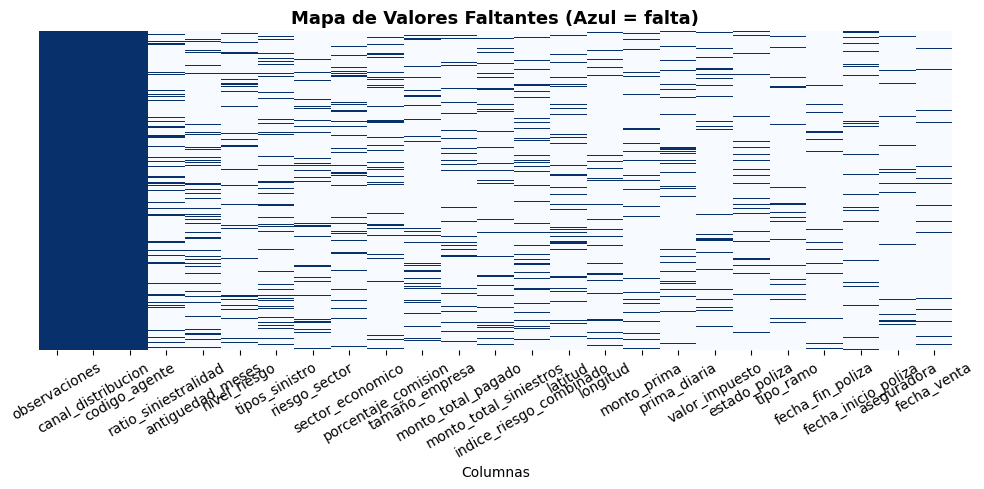

In [10]:
# 3. Mapa visual de nulos
cols_con_nulos = resumen_nulos.index.tolist()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df[cols_con_nulos].isnull(), cbar=False, cmap='Blues', yticklabels=False, ax=ax)
ax.set_title('Mapa de Valores Faltantes (Azul = falta)', fontsize=13, fontweight='bold')
ax.set_xlabel('Columnas')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [11]:
#4. Valores duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 9


In [12]:
#5. espacios en blanco
espacios_df = df.apply(lambda col: col.astype(str).str.strip() == '')
print("Espacios o celdas vacías detectados por columna:")
print(espacios_df.sum())

Espacios o celdas vacías detectados por columna:
id_venta                      0
id_poliza                     0
monto_prima                   0
porcentaje_comision           0
valor_impuesto                0
monto_total_venta             0
fecha_venta                   0
tipo_ramo                     0
fecha_inicio_poliza           0
fecha_fin_poliza              0
codigo_zona_sismica           0
nivel_riesgo                  0
estado_poliza                 0
tipo_sector                   0
ciudad                        0
departamento                  0
tamaño_empresa                0
codigo_divipola               0
nivel_riesgo_sismico          0
latitud                       0
longitud                      0
sector_economico              0
riesgo_sector                 0
aseguradora                   0
num_sinistros                 0
monto_total_siniestros        0
monto_total_pagado            0
tipos_sinistro                0
sinistros_aprobados           0
sinistros_rechazados   